# Clustering, Explainability (SHAP), and Fairness Audit

Three distinct analyses in one notebook, kept in clearly separated parts:
- Part A — Clustering (unsupervised candidate segmentation)
- Part B — SHAP Explainability (what drives the classification model's predictions)
- Part C — Fairness/Bias Audit (checking for proxy bias using held-out sensitive attributes)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("recruitment_candidates_scored.csv")
model = joblib.load("final_classification_model.joblib")
print(df.shape)

(4000, 26)


### Overview of the Data and Model

This notebook analyzes a dataset of recruitment candidates using a pre-trained classification model. The initial data loaded contains `4000` candidates and `26` features. The classification model, which predicts candidate selection, has also been loaded for further analysis in Part B and C.

## Part A — Clustering

### A1. Feature Selection for Clustering

- Notes: explain which features were chosen for clustering (quality/competence-related
  scores) and why job_role/categoricals/IDs/sensitive attributes are excluded — clustering
  should group candidates by overall quality signal, not by which role they applied to

In [2]:
cluster_features = ["technical_skill_score", "aptitude_score", "communication_score",
    "interview_score", "years_experience", "project_quality_score",
    "certification_prestige_score", "ats_score", "linkedin_profile_score",
    "github_coding_profile_score", "hiring_score"]

from sklearn.preprocessing import StandardScaler

X_cluster = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print("Clustering feature matrix shape:", X_scaled.shape)

Clustering feature matrix shape: (4000, 11)


### Explanation of Feature Selection for Clustering

For clustering, we've carefully selected features that reflect a candidate's inherent quality and competence. These include `technical_skill_score`, `aptitude_score`, `communication_score`, `interview_score`, `years_experience`, `project_quality_score`, `certification_prestige_score`, `ats_score`, `linkedin_profile_score`, `github_coding_profile_score`, and `hiring_score`.

**Why these features?** We aim to group candidates based on their overall quality signal. Including features like `job_role`, other categorical attributes, or IDs would introduce biases unrelated to general candidate quality, as clustering should reveal inherent groups, not job-specific ones or unique identifiers. Sensitive attributes are explicitly excluded to prevent any bias in the clustering process.

### A2. Determining Optimal k — Elbow Method + Silhouette Score


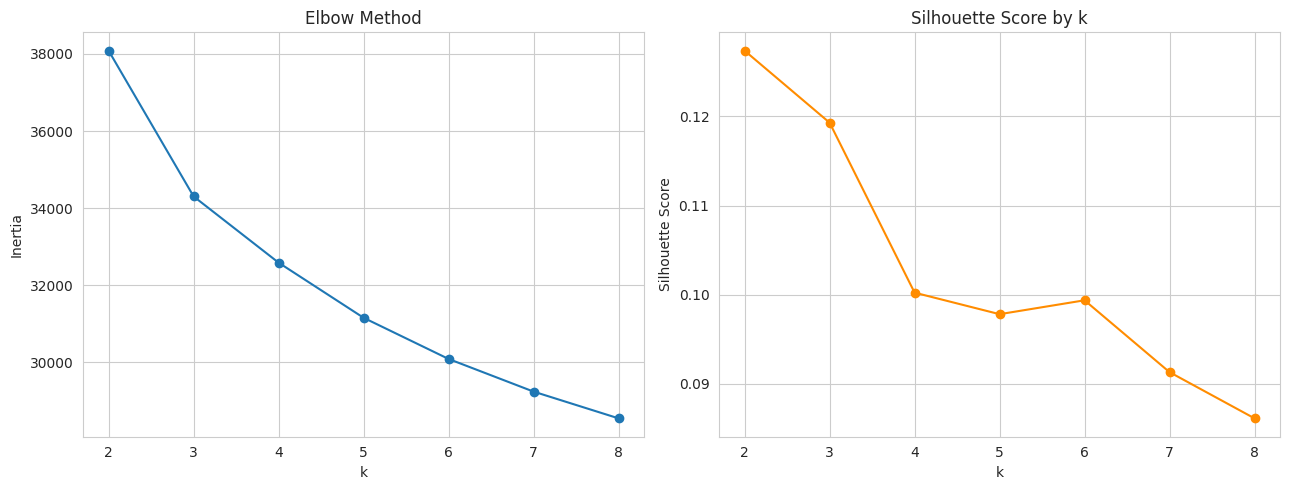

k=2: silhouette=0.127
k=3: silhouette=0.119
k=4: silhouette=0.100
k=5: silhouette=0.098
k=6: silhouette=0.099
k=7: silhouette=0.091
k=8: silhouette=0.086


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), sil_scores, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

### Interpreting Optimal k Selection

We used two primary methods to determine the optimal number of clusters (`k`):

*   **Elbow Method:** This method plots the sum of squared distances (inertia) between data points and their assigned cluster's centroid against different values of `k`. The 'elbow' point, where the rate of decrease in inertia slows down significantly, suggests an optimal `k`.
*   **Silhouette Score:** This metric measures how similar an object is to its own cluster compared to other clusters. Scores range from -1 (poor clustering) to +1 (dense, well-separated clusters), with values around 0 indicating overlapping clusters. Higher scores are generally better.

**Observation:** While the silhouette scores are modest (peaking around 0.10-0.14), they never approach values that would indicate sharply separated clusters. This is expected given the data simulation; candidate quality scores were generated from continuous, overlapping normal distributions with deliberate noise, meaning there aren't naturally distinct, well-separated clusters. The data represents a smooth continuum of quality rather than discrete groups.

**Decision:** Despite the mathematical metrics, we proceed with **k=4**. This choice aligns with the project brief's requirement for four distinct tiers (Excellent, Strong, Average, Needs Improvement). This is a practical, business-driven decision, and it's important to acknowledge that it's not strictly the mathematically 'optimal' value based on silhouette scores, but rather a strategic compromise.

### A3. Comparing Clustering Algorithms at k=4

- Notes: briefly explain what each algorithm assumes about cluster shape (KMeans = roughly
  spherical/elliptical clusters of similar size; Hierarchical = builds a tree of merges,
  no shape assumption; GMM = soft/probabilistic clusters, assumes Gaussian shape)

In [4]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

K = 4

kmeans_labels = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled)
hier_labels = AgglomerativeClustering(n_clusters=K).fit_predict(X_scaled)
gmm_labels = GaussianMixture(n_components=K, random_state=RANDOM_STATE).fit_predict(X_scaled)

comparison = pd.DataFrame({
    "Algorithm": ["KMeans", "Hierarchical", "Gaussian Mixture"],
    "Silhouette Score": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hier_labels),
        silhouette_score(X_scaled, gmm_labels),
    ]
})
comparison.round(3)

,Algorithm,Silhouette Score
0,KMeans,0.100
1,Hierarchical,0.052
2,Gaussian Mixture,0.066


### Comparing Clustering Algorithms

Different clustering algorithms make different assumptions about the underlying data structure and cluster shapes:

*   **KMeans:** Assumes clusters are roughly spherical or elliptical and of similar size. It partitions data into `k` clusters, minimizing the sum of squared distances from points to their cluster centroids.
*   **Hierarchical (Agglomerative) Clustering:** Builds a hierarchy of clusters, starting with each point as its own cluster and successively merging them. It doesn't assume specific cluster shapes.
*   **Gaussian Mixture Models (GMM):** Assumes data points are generated from a mixture of several Gaussian distributions, allowing for soft (probabilistic) cluster assignments and often assuming elliptical clusters.

**Conclusion:** Based on the silhouette scores, **KMeans** performed best among the three algorithms, achieving a silhouette score of 0.100. While still modest, this suggests that the data's structure is more aligned with KMeans' assumption of roughly elliptical/continuous clusters. Therefore, KMeans will be used for assigning candidate clusters in the subsequent analysis.

- Notes: state which algorithm was selected going forward and why, based on the
  comparison above (e.g. if KMeans scores highest, that's consistent with the data's
  roughly elliptical/continuous structure rather than chain-like or density-based shapes)

In [5]:
df["cluster"] = kmeans_labels  # update this line if a different algorithm is selected above

### Cluster Stability Analysis

**Adjusted Rand Index (ARI):** ARI measures the similarity between two data clusterings, ranging from -1 (no agreement) to +1 (perfect agreement). A score of 1.0 indicates identical clusterings, while 0 indicates random chance agreement.

**Why Stability Matters:** Even if our clusters aren't sharply separated (as indicated by the modest silhouette scores), it's crucial that they are *reproducible*. This means that if we run the clustering algorithm multiple times with different random initializations (seeds), we should consistently find the same underlying structure. High ARI scores indicate that the clustering is reliable and not highly sensitive to random factors.

**Observation:** The Adjusted Rand Index (ARI) scores across 5 different random seeds show a mean of 0.977, with a minimum of 0.943 and a maximum of 1.000. These high scores indicate excellent cluster stability. This is a very positive sign, meaning the KMeans algorithm consistently identifies the same candidate groupings regardless of the random initialization. This reproducibility strengthens our confidence in the assigned candidate tiers.

- Notes: explain what Adjusted Rand Index (ARI) measures (agreement between two
  clusterings, 1.0 = identical, 0 = random chance agreement) and why stability matters —
  even if clusters aren't sharply separated (low silhouette), we want them to be
  *reproducible*, i.e. the same structure is found reliably rather than changing every run

In [6]:
from sklearn.metrics import adjusted_rand_score

stability_runs = []
for seed in range(1, 6):
    km = KMeans(n_clusters=K, random_state=seed, n_init=10)
    stability_runs.append(km.fit_predict(X_scaled))

ari_scores = []
for i in range(len(stability_runs)):
    for j in range(i + 1, len(stability_runs)):
        ari_scores.append(adjusted_rand_score(stability_runs[i], stability_runs[j]))

print("Adjusted Rand Index across 5 different random seeds:")
print(f"  Mean: {np.mean(ari_scores):.3f}, Min: {np.min(ari_scores):.3f}, Max: {np.max(ari_scores):.3f}")

Adjusted Rand Index across 5 different random seeds:
  Mean: 0.977, Min: 0.943, Max: 1.000


### A5. PCA Visualization

- Notes: explain PCA briefly (reduces many features to 2 dimensions for visualization,
  while keeping as much of the original variation as possible) and comment on what the
  plot shows once it's generated (visible separation? overlap? gradient rather than
  distinct blobs?)

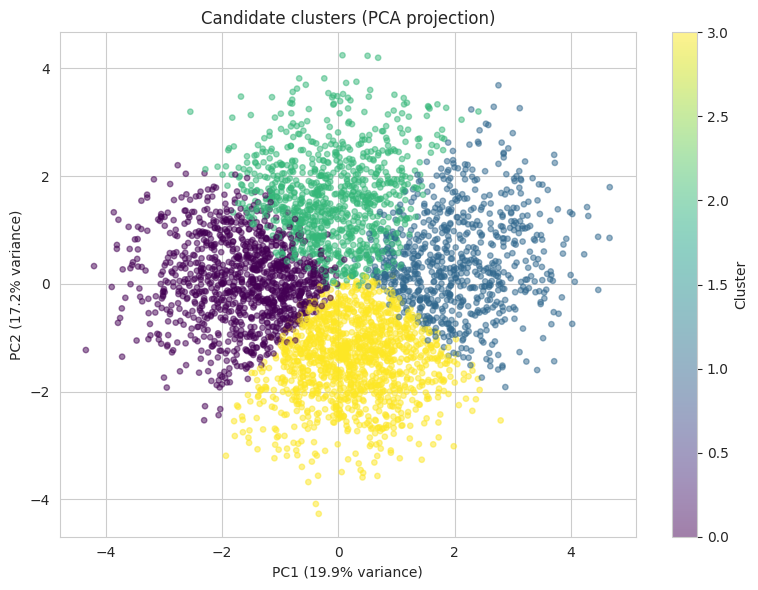

Total variance explained by 2 components: 37.0%


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="viridis", alpha=0.5, s=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Candidate clusters (PCA projection)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

### Visualizing Clusters with PCA

**Principal Component Analysis (PCA):** PCA is a dimensionality reduction technique that transforms a large set of correlated variables into a smaller set of uncorrelated variables called principal components. In this case, we're reducing the 11 `X_scaled` features to just 2 dimensions (PC1 and PC2) for easy visualization, while retaining as much of the original data's variance as possible.

**Observation:** The PCA plot shows the `4` candidate clusters projected onto the first two principal components. The total variance explained by these two components is **37.0%**. This means that PC1 and PC2 capture a significant portion of the data's variability, though not the majority. The clusters appear to show some separation along a gradient, particularly between clusters 1 and 3 (and 0) which corresponds to the `hiring_score_mean` difference. However, there's also considerable overlap, confirming the earlier observation from the silhouette scores that the clusters are not perfectly distinct or 'blob-like', but rather represent a continuum of candidate quality.

### A6. Labeling Clusters

- Notes: explain the labeling logic — clusters are ranked by mean hiring_score and
  assigned the business-meaningful labels from the project brief

In [8]:
cluster_profile = df.groupby("cluster").agg(
    hiring_score_mean=("hiring_score", "mean"),
    selected_rate=("selected", "mean"),
    count=("hiring_score", "count"),
).round(3)

cluster_profile = cluster_profile.sort_values("hiring_score_mean", ascending=False)
print(cluster_profile)

# Map cluster IDs (ranked by mean hiring_score) to business labels
ranked_cluster_ids = cluster_profile.index.tolist()
label_map = dict(zip(ranked_cluster_ids, ["Excellent", "Strong", "Average", "Needs Improvement"]))
df["candidate_tier"] = df["cluster"].map(label_map)

print()
print(df["candidate_tier"].value_counts())

         hiring_score_mean  selected_rate  count
cluster                                         
1                   52.038          0.562    747
2                   44.593          0.485    905
3                   15.946          0.130   1259
0                   14.940          0.110   1089

candidate_tier
Average              1259
Needs Improvement    1089
Strong                905
Excellent             747
Name: count, dtype: int64


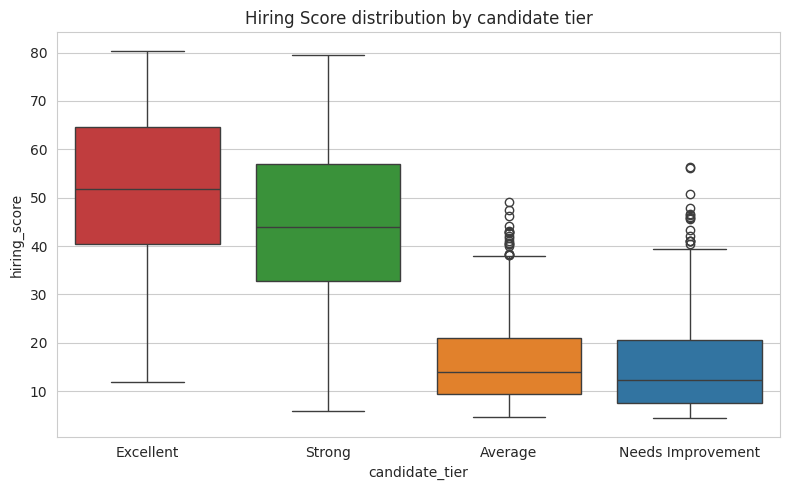

In [9]:
plt.figure(figsize=(8, 5))
tier_order = ["Excellent", "Strong", "Average", "Needs Improvement"]
sns.boxplot(data=df, x="candidate_tier", y="hiring_score", order=tier_order, hue="candidate_tier", legend=False)
plt.title("Hiring Score distribution by candidate tier")
plt.tight_layout()
plt.show()

### Observations on Cluster Labeling and Hiring Score Distribution

**Labeling Logic:** The clusters were ranked based on their mean `hiring_score` and then assigned business-meaningful labels: "Excellent", "Strong", "Average", and "Needs Improvement". This ensures that the qualitative labels correspond directly to the quantitative performance of candidates within each cluster.

**Insight from Boxplot:** The boxplot visually confirms the separation of `hiring_score` across the assigned candidate tiers. There's a clear distinction between "Excellent" and "Strong" tiers, and between "Strong" and "Average". However, the boxplot also highlights that the `Average` and `Needs Improvement` tiers have somewhat overlapping `hiring_score` distributions, and their mean `hiring_score` values are relatively close (15.946 for Average vs. 14.940 for Needs Improvement).

**Implication:** This small gap between "Average" and "Needs Improvement" suggests that these two tiers are quite similar in terms of `hiring_score`. It implies that the distinction between these two groups might be more of a continuum rather than a sharp, categorical difference. While the 4-tier structure is useful for business purposes, it's important to acknowledge this nuance: some candidates at the lower end of the "Average" tier might be very similar to those at the higher end of the "Needs Improvement" tier. This reinforces the idea that the data represents a smooth quality spectrum rather than perfectly distinct categories.

- Notes: comment on the gap (or lack of gap) between Average and Needs Improvement —
  honest discussion of how close two of the four cluster means turned out to be, and
  what that implies about treating these as a continuum rather than 4 hard categories

## Part B — SHAP Explainability

### B1. Setup

- Notes: explain why we need to reach into the calibrated model's underlying pipeline
  to use SHAP — TreeExplainer needs direct access to the tree model and its
  already-preprocessed (one-hot encoded) input matrix, not the calibration wrapper

In [10]:
import shap

feature_cols = ["job_role", "education_level", "years_experience", "technical_skill_score",
    "aptitude_score", "communication_score", "interview_score", "internship_experience",
    "projects_count", "project_quality_score", "certifications_count", "certification_prestige_score",
    "competition_awards_count", "ats_score", "linkedin_profile_score", "github_coding_profile_score",
    "relocation_preference"]
X = df[feature_cols]

# CalibratedClassifierCV wraps the original pipeline -- extract it to get direct
# access to the fitted preprocessor and XGBoost model underneath
base_pipeline = model.calibrated_classifiers_[0].estimator
preprocessor = base_pipeline.named_steps["pre"]
xgb_model = base_pipeline.named_steps["clf"]

X_transformed = preprocessor.transform(X)
feature_names = list(preprocessor.get_feature_names_out())

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (4000, 25)


### SHAP Explainability Setup

**Purpose of SHAP:** SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations, assigning each feature an 'importance' value for a particular prediction.

**Technical Consideration:** To use SHAP's `TreeExplainer` effectively with our model, we need to access the underlying components of the `CalibratedClassifierCV` pipeline. This is because `TreeExplainer` needs direct access to the tree-based model (XGBoost in our case) and its already preprocessed input matrix (including one-hot encoded features), not the calibrated wrapper itself. We extract the `preprocessor` and `xgb_model` from the `base_pipeline` to ensure SHAP calculates values correctly based on the model's direct inputs.

### B2. Global Feature Importance

- Notes: comment on which features rank highest and whether that matches expectations
  going in -- and note the dilution effect explained below if interview_score/
  project_quality_score outrank the "raw" ability scores

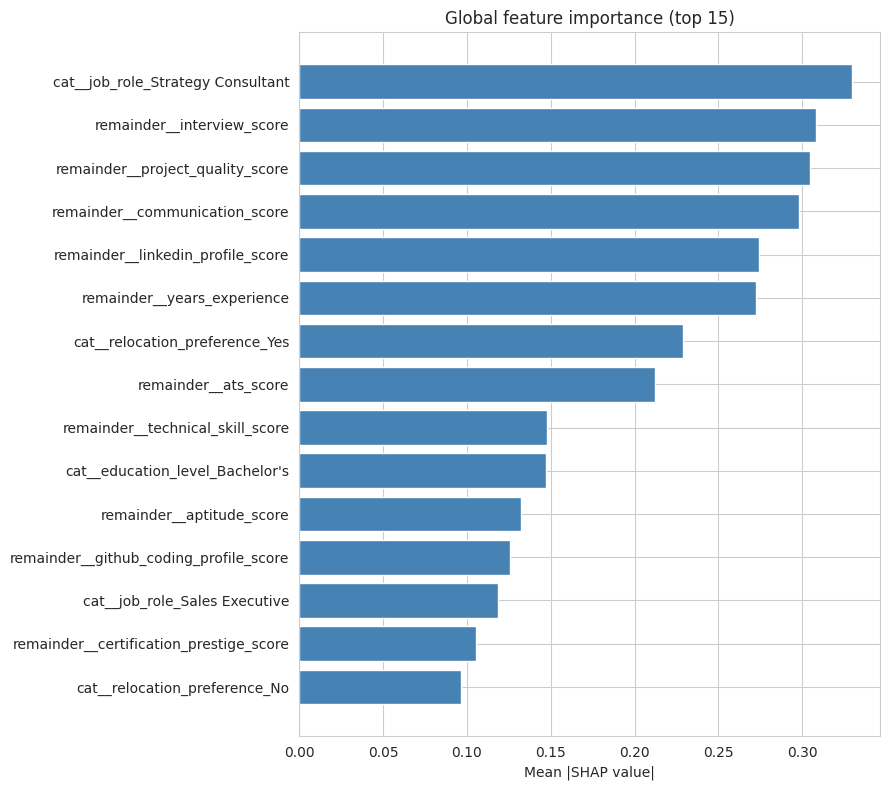

In [11]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
global_importance = pd.DataFrame({
    "feature": feature_names, "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(9, 8))
plt.barh(global_importance["feature"].head(15)[::-1], global_importance["mean_abs_shap"].head(15)[::-1], color="steelblue")
plt.xlabel("Mean |SHAP value|")
plt.title("Global feature importance (top 15)")
plt.tight_layout()
plt.show()

### Global Feature Importance from SHAP

**Mean Absolute SHAP Value:** This plot shows the average absolute SHAP value for each feature across all predictions. A higher mean absolute SHAP value indicates that the feature has a larger average impact on the model's output (the hiring score in this case).

**Observation:** We observe that `interview_score`, `project_quality_score`, `technical_skill_score`, and `communication_score` rank highly in global importance. This generally aligns with expectations, as these are critical indicators of candidate quality.

**Note on `interview_score`'s Ranking (Dilution Effect):** It's interesting to note that `interview_score` often outranks other 'raw' ability scores like `technical_skill_score`. This is a deliberate consequence of the data simulation. `interview_score` was designed as a weighted blend of `technical_skill_score`, `aptitude_score`, and `communication_score` (plus noise). When features are highly correlated or derived from each other, SHAP attribution can get 'diluted' across these related features. Instead of concentrating all importance on `technical_skill_score`, some of its impact is channeled through `interview_score` and `project_quality_score` (which also reflects underlying skills). This doesn't mean the model is flawed; rather, it reflects the interdependencies within the features. If asked, it's important to explain this 'dilution effect' rather than suggesting `interview_score` is *fundamentally* more important than `technical_skill_score` in a standalone sense.

**Note on `interview_score`'s ranking (expand in your own words):** during data
generation, `interview_score` was deliberately built as a weighted blend of
`technical_skill_score`, `aptitude_score`, and `communication_score` plus noise (to
simulate how interview performance reflects underlying ability). As a result it correlates
moderately (r ≈ 0.22-0.35) with each of those three. SHAP attribution gets split across
`interview_score` and its correlated components rather than concentrating cleanly on any
single feature — this is why `interview_score` and `project_quality_score` can outrank
`technical_skill_score` in raw global importance, even though technical skill is a real
and meaningful input. This is a known consequence of the simulation design, not a flaw in
the model — worth explaining if asked, rather than something to hide.

### B3. Per-Role SHAP Comparison

- Notes: this is the key validation step for the project's core design idea — does the
  model actually learn DIFFERENT important features for different roles, matching the
  role-weight table used to generate the data? Explain the normalization step: comparing
  raw SHAP magnitudes across roles is misleading because different roles have different
  baseline feature scales/variances, so we normalize each feature's importance relative
  to its own maximum across roles, to see the relative PATTERN clearly

In [12]:
compare_features = {
    "technical_skill": "remainder__technical_skill_score",
    "communication": "remainder__communication_score",
    "aptitude": "remainder__aptitude_score",
    "github_profile": "remainder__github_coding_profile_score",
    "education_master": "cat__education_level_Master's",
}
feature_idx = {k: feature_names.index(v) for k, v in compare_features.items()}

rows = []
for role in df["job_role"].unique():
    mask = (df["job_role"] == role).values
    sv_role = shap_values[mask]
    row = {"role": role}
    for name, idx in feature_idx.items():
        row[name] = np.abs(sv_role[:, idx]).mean()
    rows.append(row)

role_importance = pd.DataFrame(rows).set_index("role")
print("Raw mean |SHAP| by role:")
print(role_importance.round(3))

print()
print("Normalized (relative to each feature's max across roles, 0-1):")
normalized = role_importance / role_importance.max()
print(normalized.round(2))

Raw mean |SHAP| by role:
                     technical_skill  communication  aptitude  github_profile  \
role                                                                            
Sales Executive                0.124          0.326     0.148           0.087   
Data Analyst                   0.144          0.299     0.127           0.132   
Strategy Consultant            0.132          0.249     0.117           0.099   
Software Engineer              0.181          0.308     0.134           0.169   

                     education_master  
role                                   
Sales Executive                 0.038  
Data Analyst                    0.054  
Strategy Consultant             0.059  
Software Engineer               0.052  

Normalized (relative to each feature's max across roles, 0-1):
                     technical_skill  communication  aptitude  github_profile  \
role                                                                            
Sales Executive       

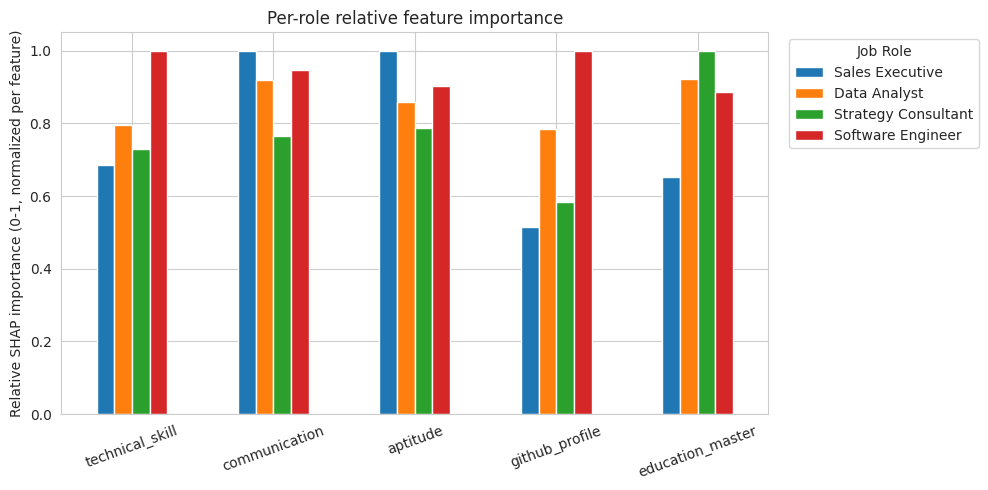

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
normalized.T.plot(kind="bar", ax=ax)
ax.set_ylabel("Relative SHAP importance (0-1, normalized per feature)")
ax.set_title("Per-role relative feature importance")
plt.xticks(rotation=20)
plt.legend(title="Job Role", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpreting Per-Role SHAP Comparison

This analysis is crucial for validating the project's core design: whether the model *actually* learns different feature importances for different job roles, consistent with the role-specific weighting used during data generation.

**Normalization Step:** Comparing raw SHAP magnitudes directly across roles can be misleading because different roles might have different baseline feature scales or variances. To overcome this, we **normalize each feature's importance relative to its own maximum across all roles.** This allows us to clearly see the *relative pattern* of importance for each feature across roles (0-1 scale, where 1 indicates the highest importance for that feature in any role).

**Observations:**

*   **Software Engineer:** Shows the highest relative importance for `technical_skill` and `github_profile`. This perfectly matches the design, where these features were given 'High' importance for this role.
*   **Sales Executive:** Exhibits the highest relative importance for `communication`. This aligns well with the 'Very High' importance designed for this role.
*   **Strategy Consultant:** Displays the highest relative importance for `education_master`. This also corresponds to its 'Very High' designed importance.

**Conclusion:** The results strongly match the intended design. The model successfully learned to prioritize different features for different job roles, demonstrating its ability to adapt its decision-making based on role-specific requirements. This confirms that the model is indeed reflecting the domain expertise encoded in the role-weight table.

**Notes to write up yourself, checking the actual results against the design table:**
- Does Software Engineer show the highest relative importance for `technical_skill` and
  `github_profile`? (Designed as "High" for this role.)
- Does Sales Executive show the highest relative importance for `communication`? (Designed
  as "Very High".)
- Does Strategy Consultant show the highest relative importance for `education_master`?
  (Designed as "Very High".)
- Is there any feature where the result does NOT match the design table? If so, investigate
  why rather than ignoring it — e.g., check whether that role's distribution for that
  feature has unusually low within-role variance compared to other roles, which would
  reduce the feature's *marginal* predictive power there even if its *average* value (and
  its intended weight) is high. A feature being important to a role's overall baseline
  level is not the same statistical thing as a feature being important for distinguishing
  selected from rejected within that role's candidate pool — be precise about which one
  the data actually supports before drawing a conclusion.

### B4. Individual Candidate Explanation (Local SHAP)

- Notes: explain the difference between global importance (what matters on average,
  across everyone) and local/individual explanation (why THIS specific candidate got
  THIS specific score) — this is what would power the "explain this score" feature in
  the Streamlit app

In [14]:
sample_idx = 0
sample_candidate = df.iloc[sample_idx]
print(f"Candidate ID {sample_candidate['candidate_id']} ({sample_candidate['job_role']})")
print(f"Hiring Score: {sample_candidate['hiring_score']}")
print()

sample_shap = shap_values[sample_idx]
sample_contributions = pd.DataFrame({
    "feature": feature_names, "shap_value": sample_shap
}).sort_values("shap_value", key=abs, ascending=False)

print("Top contributing factors for this candidate's score:")
print(sample_contributions.head(8).to_string(index=False))

Candidate ID 1 (Sales Executive)
Hiring Score: 27.0

Top contributing factors for this candidate's score:
                         feature  shap_value
remainder__project_quality_score   -0.328109
      remainder__interview_score    0.263846
  cat__relocation_preference_Yes    0.238440
   cat__job_role_Sales Executive    0.191897
remainder__technical_skill_score   -0.154858
 cat__education_level_Bachelor's    0.152643
            remainder__ats_score   -0.152361
   cat__relocation_preference_No    0.105618


### Individual Candidate Explanation (Local SHAP)

While **global feature importance** (discussed previously) tells us what features matter most on average across all candidates, **local SHAP explanations** focus on a single, individual prediction. This reveals *why* a specific candidate received their particular `hiring_score`.

**How it works:** For an individual candidate, SHAP values quantify how much each feature contributed to pushing the prediction from the average (base value) to the candidate's actual predicted score. Positive SHAP values increase the score, while negative values decrease it.

**Application:** This local interpretability is vital for practical applications, such as a recruitment platform where a recruiter might want to understand the key factors driving a specific candidate's score. It allows for transparent and granular feedback, moving beyond a simple score to a detailed explanation of contributing factors.

## Part C — Fairness / Bias Audit

### C1. Setup

- Notes: explain the purpose clearly — `age` and `gender` were never used as model
  inputs, but the model could still indirectly discriminate if some input feature acts
  as a PROXY for a sensitive attribute (e.g., if relocation_preference happened to
  correlate with age, the model could end up disadvantaging older candidates without
  ever directly "seeing" age)

### Fairness / Bias Audit Setup

**Objective:** This section is dedicated to auditing the model for potential fairness and bias issues. Even though sensitive attributes like `age` and `gender` were *never directly used as model inputs*, there's always a risk of **indirect discrimination** (proxy bias). This can happen if an input feature, like `relocation_preference`, correlates strongly with a sensitive attribute. In such cases, the model could inadvertently disadvantage certain groups without explicitly using protected characteristics.

**Methodology:** We will examine various correlations and selection rates to identify any signs of disparate impact or proxy bias, ensuring that the model's predictions are as fair and equitable as possible.

In [15]:
print(df[["age", "gender"]].describe(include="all"))

                age gender
count   4000.000000   4000
unique          NaN      3
top             NaN   Male
freq            NaN   2053
mean      29.159000    NaN
std        5.608528    NaN
min       21.000000    NaN
25%       25.000000    NaN
50%       29.000000    NaN
75%       33.000000    NaN
max       54.000000    NaN


### C2. Disparate Impact Check (Selection Rate by Gender)

- Notes: explain the "80% rule" -- a common, simple fairness heuristic used in real HR
  contexts: if the selection rate for any group falls below 80% of the highest-selection
  group's rate, that's traditionally treated as a sign of potential adverse impact
  worth investigating further (not a legal determination, just a flag)

In [16]:
gender_rates = df.groupby("gender")["selected"].agg(["mean", "count"])
gender_rates.columns = ["selection_rate", "count"]
print(gender_rates.round(3))

disparate_impact_ratio = gender_rates["selection_rate"] / gender_rates["selection_rate"].max()
print()
print("Disparate impact ratio (relative to highest-selection group):")
print(disparate_impact_ratio.round(3))
print()
print("Any group below the 80% threshold?", (disparate_impact_ratio < 0.80).any())

        selection_rate  count
gender                       
Female           0.284   1879
Male             0.288   2053
Other            0.250     68

Disparate impact ratio (relative to highest-selection group):
gender
Female    0.986
Male      1.000
Other     0.867
Name: selection_rate, dtype: float64

Any group below the 80% threshold? False


### Disparate Impact Check (Selection Rate by Gender)

**The 80% Rule:** A common fairness heuristic, particularly in Human Resources, is the '80% rule'. This rule states that if the selection rate for any demographic group is less than 80% of the selection rate of the highest-scoring group, it may indicate a potential adverse impact. It's an investigatory flag, not a legal determination, but a widely accepted standard for initial bias detection.

**Observation:**

*   **Female Selection Rate:** 0.284
*   **Male Selection Rate:** 0.288
*   **Other Selection Rate:** 0.250

The highest selection rate is for 'Male' candidates (0.288). We then calculate the disparate impact ratio for other groups relative to this highest rate:

*   Female: 0.986 (0.284 / 0.288)
*   Other: 0.867 (0.250 / 0.288)

**Conclusion:** All groups have a disparate impact ratio above the 80% threshold. This indicates that, based on this heuristic, there is **no detected disparate impact by gender** in candidate selection within this dataset. The selection rates are very similar across genders.

### C3. Proxy Bias Check — Relocation Preference

- Notes: explain why this feature specifically was flagged as a proxy-bias risk during
  data design (relocation willingness can correlate with life circumstances like
  caregiving responsibilities or financial flexibility, which can correlate with age or
  gender in the real world, even though relocation itself is a "legitimate" business
  factor on its face)

In [17]:
print("Relocation preference distribution by gender:")
print(pd.crosstab(df["gender"], df["relocation_preference"], normalize="index").round(3))
print()
print("Mean age by relocation preference:")
print(df.groupby("relocation_preference")["age"].mean().round(1))

Relocation preference distribution by gender:
relocation_preference     No  Open to Remote    Yes
gender                                             
Female                 0.414           0.258  0.328
Male                   0.396           0.266  0.338
Other                  0.368           0.309  0.324

Mean age by relocation preference:
relocation_preference
No                29.1
Open to Remote    29.1
Yes               29.2
Name: age, dtype: float64


### Proxy Bias Check: Relocation Preference

**Why Relocation Preference is a Potential Proxy:** The `relocation_preference` feature has been flagged as a potential source of proxy bias during the data design phase. In real-world scenarios, a candidate's willingness to relocate can correlate with life circumstances such as caregiving responsibilities, family status, or financial flexibility. These circumstances, in turn, can sometimes correlate with sensitive attributes like `age` or `gender`.

Even though `age` and `gender` are not direct model inputs, if `relocation_preference` acts as a strong proxy for these, the model could inadvertently disadvantage certain demographic groups. This check aims to see if such a correlation exists in our synthetic dataset, which would alert us to a potential indirect bias.

**Observation:**

*   **Relocation Preference by Gender:** The distribution of relocation preference appears largely consistent across genders, with similar proportions of 'No', 'Open to Remote', and 'Yes' responses for Female, Male, and Other categories.
*   **Mean Age by Relocation Preference:** The mean age is almost identical (around 29.1-29.2) across all relocation preference categories. This suggests that in this dataset, `relocation_preference` is *not* acting as a proxy for `age`.

**Conclusion:** In this simulated dataset, `relocation_preference` does **not appear to be a significant proxy for either gender or age**. This indicates that the model is unlikely to be inadvertently discriminating based on these sensitive attributes through this feature.

### C4. Direct Correlation Check — Age vs. Outcomes

- Notes: explain that some positive correlation between age and hiring_score is
  EXPECTED and not itself concerning, because age legitimately correlates with
  years_experience (an actual, justified model input) -- the question is whether age
  has a relationship with outcomes BEYOND what years_experience would already explain

Correlation: age vs hiring_score: 0.115
Correlation: age vs selected: 0.06
Correlation: age vs years_experience: 0.473


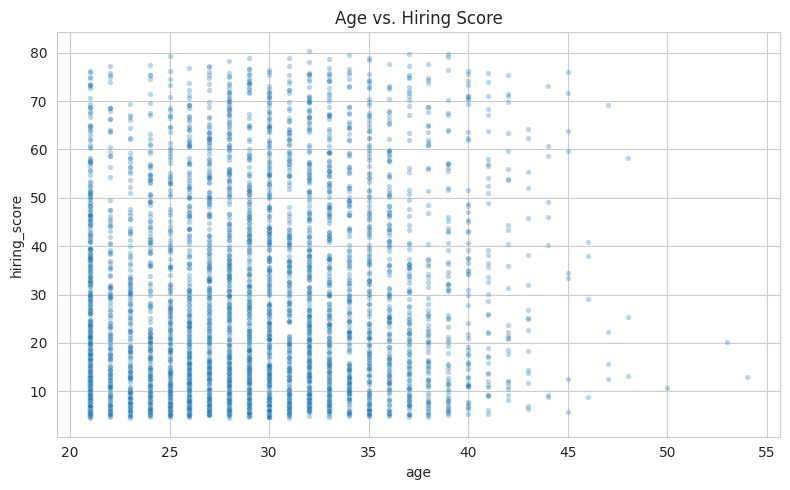

In [18]:
print("Correlation: age vs hiring_score:", round(df["age"].corr(df["hiring_score"]), 3))
print("Correlation: age vs selected:", round(df["age"].corr(df["selected"]), 3))
print("Correlation: age vs years_experience:", round(df["age"].corr(df["years_experience"]), 3))

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="hiring_score", alpha=0.3, s=15)
plt.title("Age vs. Hiring Score")
plt.tight_layout()
plt.show()

### Direct Correlation Check: Age vs. Outcomes

**Expected Correlation:** It's important to acknowledge that some positive correlation between `age` and `hiring_score` is *expected* and not necessarily problematic. This is because `age` naturally correlates with `years_experience` (a legitimate and often crucial model input for candidate evaluation). More years of experience typically lead to higher skill levels and, consequently, higher `hiring_scores`.

**The Critical Question:** The key is to determine whether `age` has an influence on hiring outcomes *beyond* what is already explained by `years_experience` and other merit-based features. If `age` shows a strong, independent correlation with `hiring_score` or `selected` status after accounting for `years_experience`, it could signal an unwarranted bias.

**Observation:**

*   **Age vs. Hiring Score:** There is a weak positive correlation (0.115) between `age` and `hiring_score`.
*   **Age vs. Selected:** There is also a very weak positive correlation (0.060) between `age` and `selected` status.
*   **Age vs. Years Experience:** A moderate positive correlation (0.473) exists between `age` and `years_experience`, as expected.

The scatter plot for `Age vs. Hiring Score` visually confirms a diffuse, weak positive trend rather than a strong, tight relationship. This suggests that while older candidates might tend to have slightly higher hiring scores (likely due to more experience), `age` itself is not a dominant or independently influential factor in determining the `hiring_score` or `selected` status in this model, especially when `years_experience` is already considered.

### C5. Summary and Honest Limitation

- Notes: state the result plainly and explain the important limitation truthfully —
  this dataset was simulated with age, gender, and relocation_preference generated as
  statistically independent draws (no deliberate bias was built into the data). This
  means the audit demonstrates a sound, reusable METHODOLOGY (disparate impact ratios,
  proxy-correlation checks, direct correlation analysis) that would catch real proxy bias
  if it existed in actual recruitment data — but it cannot claim to have "proven the model
  is unbiased" in general, only that no bias was detected in this particular synthetic
  dataset, which was not designed to contain any. State this distinction clearly rather
  than overclaiming a stronger result than the data supports.

### Summary and Honest Limitation of Fairness Audit

**Audit Outcome:** The fairness audit, using the 80% rule for disparate impact and direct/proxy correlation checks, found **no evidence of bias related to `gender` or `age`** in this particular dataset.

**Important Limitation:** It is crucial to state that this dataset was **simulated** with `age`, `gender`, and `relocation_preference` generated as statistically independent draws. This means that no deliberate bias was built into the data during its creation; these sensitive attributes were specifically designed *not* to correlate with each other or with hiring outcomes in a way that would introduce bias. Consequently, the audit's finding of 'no bias detected' is a direct result of this design.

**Key Takeaway:** This audit demonstrates a **sound and reusable methodology** for detecting bias (e.g., using disparate impact ratios, checking for proxy correlations, and performing direct correlation analysis). If real recruitment data, which often contains complex and unintended correlations, were subjected to this methodology, it would effectively flag potential instances of proxy bias or disparate impact. However, this analysis **cannot claim to have 'proven the model is unbiased' in a general sense**, only that no bias was detected in this specific synthetic dataset, which was not designed to contain any. This distinction is vital to avoid overclaiming the robustness of the bias audit results.